In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# =========================
# Load data
# =========================
# Load dataset to start preprocessing and feature engineering

df = pd.read_csv("/content/features_DataSet (1).csv")
print(df.columns)

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Street',
       'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       ...
       'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM',
       'price_per_sqft', 'total_bathrooms', 'age_at_sale', 'quality_x_area',
       'SalePrice_log', 'age_group'],
      dtype='object', length=113)


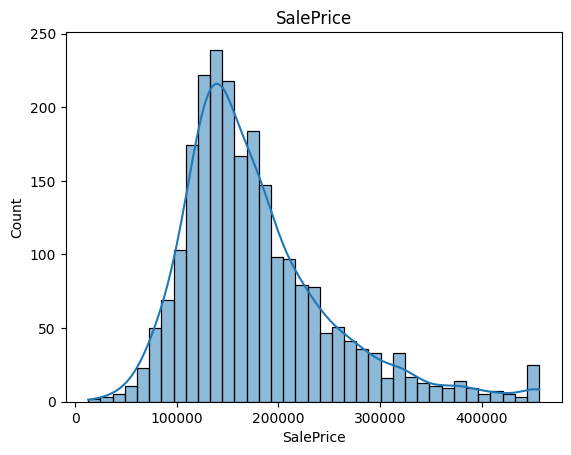

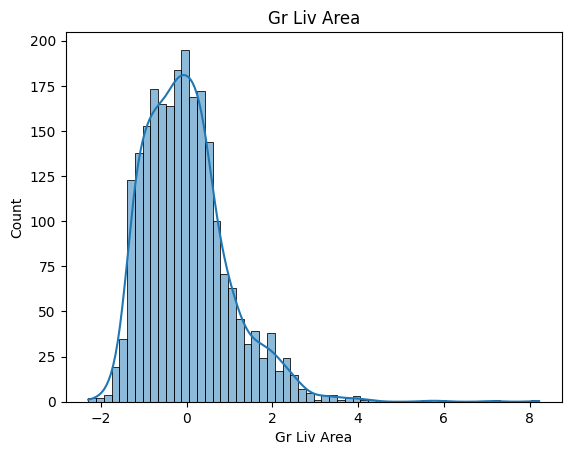

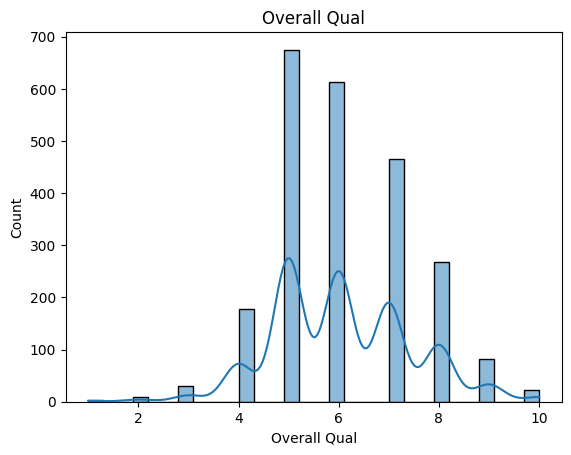

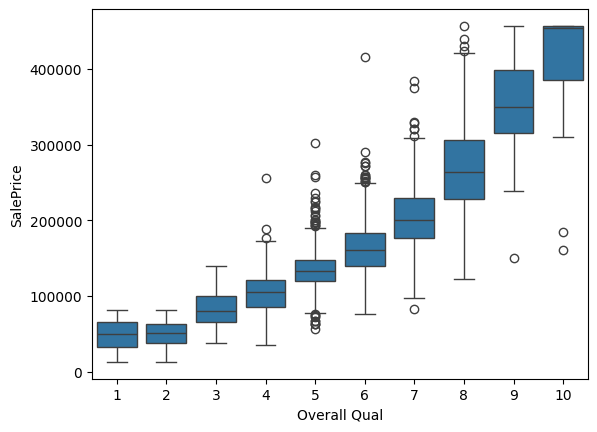

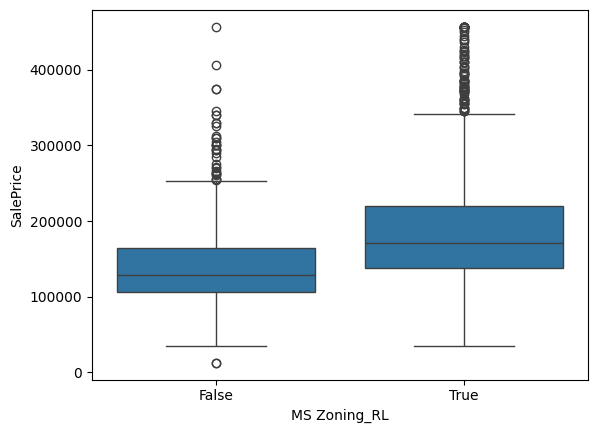

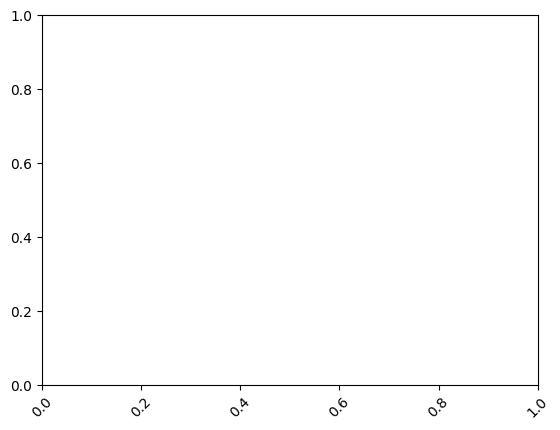

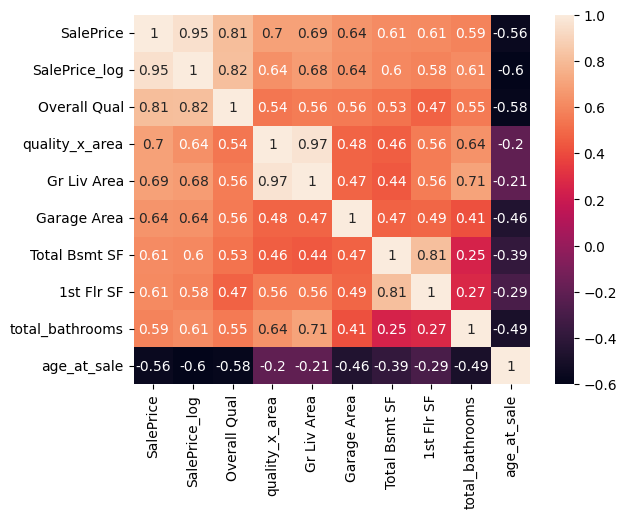

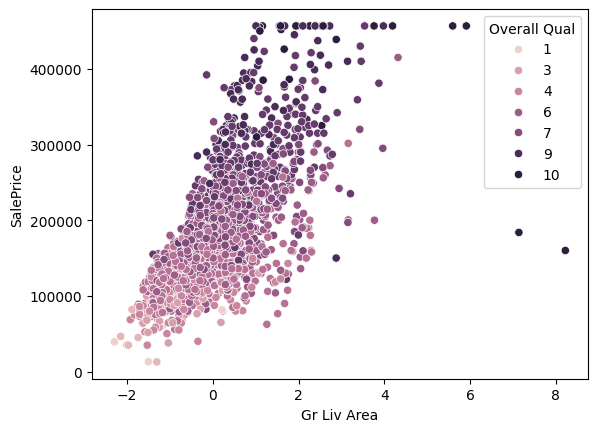

MS Zoning_RL
False    143072.187015
True     188001.564026
Name: SalePrice, dtype: float64
MS Zoning_RL
False    143072.187015
True     188001.564026
Name: SalePrice, dtype: float64


In [22]:
# =========================
# 1) Histograms / KDE
# =========================
# Distribution of numerical features

plt.figure()
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice")
plt.show()

plt.figure()
sns.histplot(df["Gr Liv Area"], kde=True)
plt.title("Gr Liv Area")
plt.show()

plt.figure()
sns.histplot(df["Overall Qual"], kde=True)
plt.title("Overall Qual")
plt.show()


# =========================
# 2) Grouped Boxplots
# =========================
# Compare SalePrice across categories

plt.figure()
sns.boxplot(x="Overall Qual", y="SalePrice", data=df)
plt.show()

plt.figure()
sns.boxplot(x="MS Zoning_RL", y="SalePrice", data=df)
plt.show()

plt.xticks(rotation=45)


# =========================
# 3) Correlation Heatmap
# =========================
# Top 10 correlated features with SalePrice

corr = df.corr(numeric_only=True)

top_cols = corr["SalePrice"].abs().sort_values(ascending=False).head(10).index

plt.figure()
sns.heatmap(df[top_cols].corr(), annot=True)
plt.show()


# =========================
# 4) Scatter Plot
# =========================
# Relationship between area and price

plt.figure()
sns.scatterplot(
    x="Gr Liv Area",
    y="SalePrice",
    hue="Overall Qual",
    data=df
)
plt.show()


# =========================
# 5) GroupBy Summary
# =========================
# Mean SalePrice per zoning

group = df.groupby("MS Zoning_RL")["SalePrice"].mean().sort_values()

print(group.head())
print(group.tail())

In [23]:

# =========================
# 1) Mean & Standard Deviation (Manual)
# =========================
# Convert target column to NumPy array for calculations
y = df["SalePrice"].values

# Compute mean (average value of house prices)
mean = np.sum(y) / len(y)

# Compute standard deviation (how spread out the values are)
std = np.sqrt(np.sum((y - mean) ** 2) / len(y))

print("Mean:", mean)
print("Std:", std)


# =========================
# 2) Standardization (Z-score)
# =========================
# Select house area feature
X = df["Gr Liv Area"].values

# Manual standardization (scale data to mean=0, std=1)
z_manual = (X - np.mean(X)) / np.std(X)

# StandardScaler from sklearn for verification
scaler = StandardScaler()
z_sklearn = scaler.fit_transform(df[["Gr Liv Area"]]).flatten()

print("\nManual vs Sklearn (first 5):")
print(z_manual[:5])
print(z_sklearn[:5])


# =========================
# 3) Cosine Similarity
# =========================
# Select the most expensive and cheapest houses
high = df.loc[[df["SalePrice"].idxmax()]]
low = df.loc[[df["SalePrice"].idxmin()]]

# Select only numeric features for comparison
features = df.drop(columns=["SalePrice"]).select_dtypes(include=np.number).columns

# Convert both houses into feature vectors
v1 = high[features].values.flatten()
v2 = low[features].values.flatten()

# Compute cosine similarity between two houses
cos_sim = np.dot(v1, v2) / (norm(v1) * norm(v2))

print("\nCosine Similarity:", cos_sim)

# Interpretation:
# 1 = very similar
# 0 = very different


# =========================
# 4) Probability Estimation
# =========================
# Define expensive houses as top 25% of prices
threshold = df["SalePrice"].quantile(0.75)

# Select high-quality houses
high_quality = df[df["Overall Qual"] >= 7]

# Calculate probability that high-quality houses are expensive
prob = (high_quality["SalePrice"] > threshold).mean()

print("\nProbability:", prob)

Mean: 177919.28915102387
Std: 73907.81713978769

Manual vs Sklearn (first 5):
[-0.24352173  1.25495594 -0.53291028 -0.89761913  0.41255778]
[-0.24352173  1.25495594 -0.53291028 -0.89761913  0.41255778]

Cosine Similarity: 0.9999999437500334

Probability: 0.6191616766467066


In [24]:
df.to_csv("Phase3_DataSet.csv", index=False)

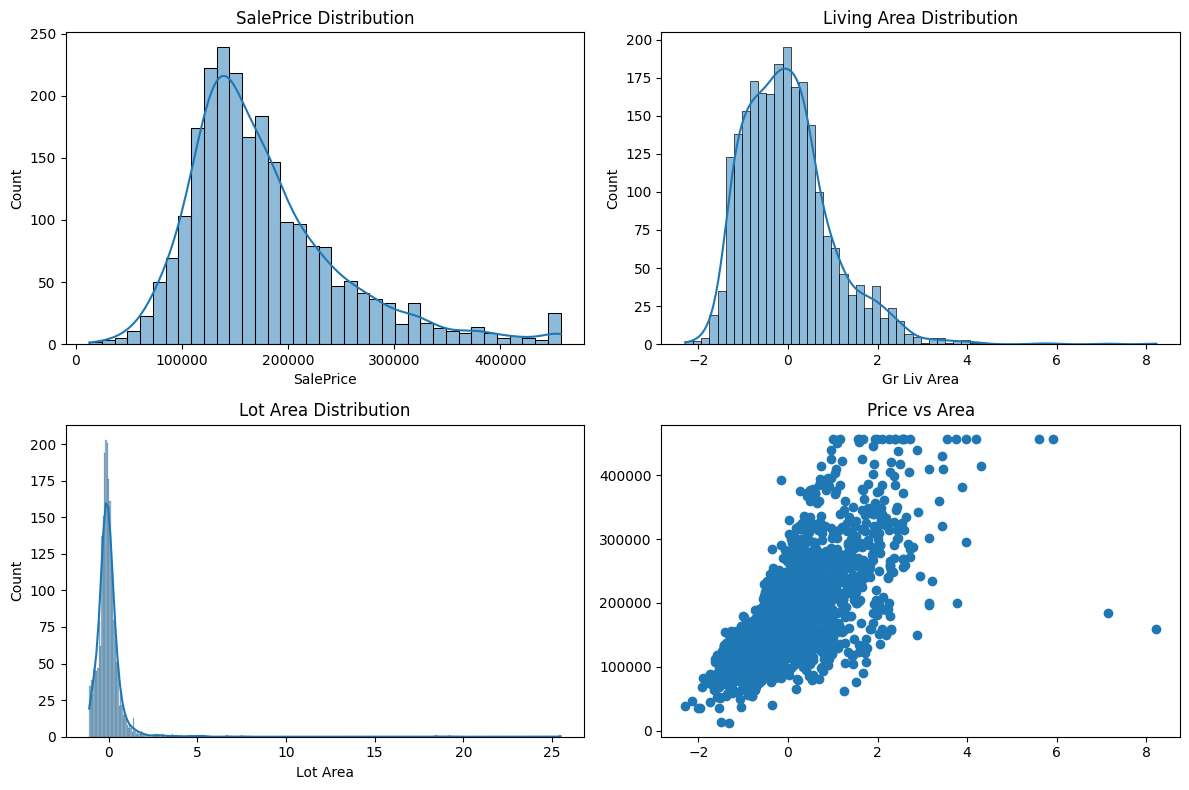

In [25]:
# Create simple dashboard using subplots
# Combine multiple visualizations in one figure for better comparison

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. SalePrice distribution
sns.histplot(df["SalePrice"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("SalePrice Distribution")

# 2. Gr Liv Area distribution
sns.histplot(df["Gr Liv Area"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Living Area Distribution")

# 3. Lot Area distribution
sns.histplot(df["Lot Area"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Lot Area Distribution")

# 4. Correlation between SalePrice and Gr Liv Area
axes[1, 1].scatter(df["Gr Liv Area"], df["SalePrice"])
axes[1, 1].set_title("Price vs Area")

plt.tight_layout()
plt.show()